In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
df = pd.read_csv(r"C:\Users\Aparna Mondal\Downloads\EV_Dataset.csv")

In [3]:
print("Dataset Overview:")
display(df.head())
print("\nDataset Info:")
df.info()


Dataset Overview:


,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity
0,2014.0,jan,1/1/2014,Andhra Pradesh,ADAPTED VEHICLE,Others,Others,0.0
1,2014.0,jan,1/1/2014,Andhra Pradesh,AGRICULTURAL TRACTOR,Others,Others,0.0
2,2014.0,jan,1/1/2014,Andhra Pradesh,AMBULANCE,Others,Others,0.0
3,2014.0,jan,1/1/2014,Andhra Pradesh,ARTICULATED VEHICLE,Others,Others,0.0
4,2014.0,jan,1/1/2014,Andhra Pradesh,BUS,Bus,Bus,0.0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               96845 non-null  float64
 1   Month_Name         96845 non-null  object 
 2   Date               96845 non-null  object 
 3   State              96845 non-null  object 
 4   Vehicle_Class      96845 non-null  object 
 5   Vehicle_Category   96845 non-null  object 
 6   Vehicle_Type       96845 non-null  object 
 7   EV_Sales_Quantity  96845 non-null  float64
dtypes: float64(2), object(6)
memory usage: 5.9+ MB


In [4]:
df.shape

(96845, 8)

In [5]:
print("Dataset Overview:")
display(df.head())
print("\nDataset Info:")
df.info()

Dataset Overview:


,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity
0,2014.0,jan,1/1/2014,Andhra Pradesh,ADAPTED VEHICLE,Others,Others,0.0
1,2014.0,jan,1/1/2014,Andhra Pradesh,AGRICULTURAL TRACTOR,Others,Others,0.0
2,2014.0,jan,1/1/2014,Andhra Pradesh,AMBULANCE,Others,Others,0.0
3,2014.0,jan,1/1/2014,Andhra Pradesh,ARTICULATED VEHICLE,Others,Others,0.0
4,2014.0,jan,1/1/2014,Andhra Pradesh,BUS,Bus,Bus,0.0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               96845 non-null  float64
 1   Month_Name         96845 non-null  object 
 2   Date               96845 non-null  object 
 3   State              96845 non-null  object 
 4   Vehicle_Class      96845 non-null  object 
 5   Vehicle_Category   96845 non-null  object 
 6   Vehicle_Type       96845 non-null  object 
 7   EV_Sales_Quantity  96845 non-null  float64
dtypes: float64(2), object(6)
memory usage: 5.9+ MB


In [6]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Year                 0
Month_Name           0
Date                 0
State                0
Vehicle_Class        0
Vehicle_Category     0
Vehicle_Type         0
EV_Sales_Quantity    0
dtype: int64


In [7]:
print("\nBasic Statistics:")
display(df.describe())



Basic Statistics:


,Year,EV_Sales_Quantity
count,96845.000000,96845.000000
mean,2018.622768,37.108896
std,2.895581,431.566675
min,2014.000000,0.000000
25%,2016.000000,0.000000
50%,2019.000000,0.000000
75%,2021.000000,0.000000
max,2024.000000,20584.000000


In [8]:
import pandas as pd

# Convert 'Year' to integer
df['Year'] = df['Year'].astype(int)

# Standardize 'Month_Name' (capitalize first letter)
df['Month_Name'] = df['Month_Name'].str.capitalize()

# Convert 'Date' to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')

# Verify changes
print(df.dtypes)
print(df[['Year', 'Month_Name', 'Date']].head())


Year                          int32
Month_Name                   object
Date                 datetime64[ns]
State                        object
Vehicle_Class                object
Vehicle_Category             object
Vehicle_Type                 object
EV_Sales_Quantity           float64
dtype: object
   Year Month_Name       Date
0  2014        Jan 2014-01-01
1  2014        Jan 2014-01-01
2  2014        Jan 2014-01-01
3  2014        Jan 2014-01-01
4  2014        Jan 2014-01-01


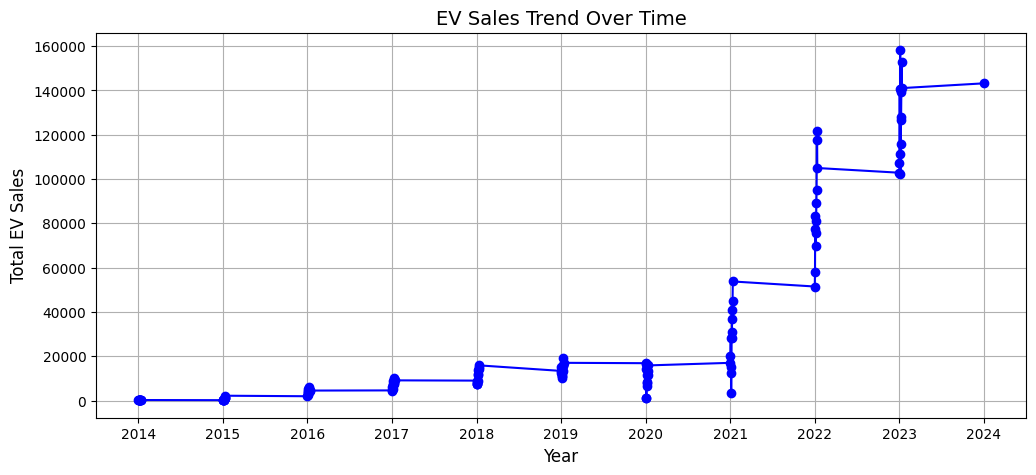

In [9]:
import matplotlib.pyplot as plt

# Aggregate EV sales by Date
ev_sales_trend = df.groupby('Date')['EV_Sales_Quantity'].sum()

# Plot sales over time
plt.figure(figsize=(12, 5))
plt.plot(ev_sales_trend.index, ev_sales_trend.values, marker='o', linestyle='-', color='b')
plt.title("EV Sales Trend Over Time", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total EV Sales", fontsize=12)
plt.grid()
plt.show()


EV Sales by State
Check which states contribute the most to EV sales:

C:\Users\Aparna Mondal\AppData\Local\Temp\ipykernel_24532\3150373355.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_sales.head(10).values, y=state_sales.head(10).index, palette="viridis")


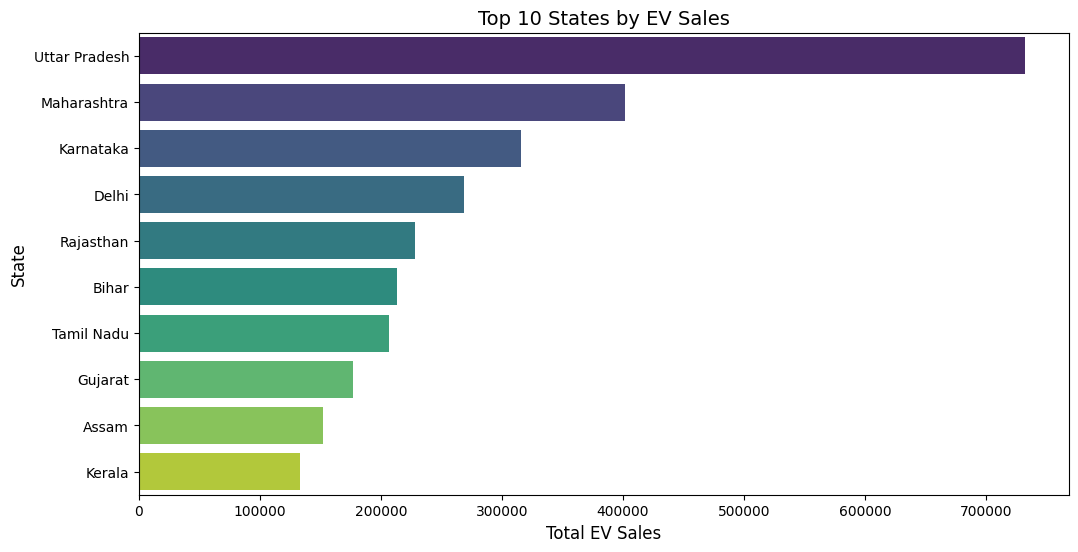

In [10]:
import seaborn as sns

# Aggregate EV sales by State
state_sales = df.groupby('State')['EV_Sales_Quantity'].sum().sort_values(ascending=False)

# Plot the top 10 states
plt.figure(figsize=(12, 6))
sns.barplot(x=state_sales.head(10).values, y=state_sales.head(10).index, palette="viridis")
plt.title("Top 10 States by EV Sales", fontsize=14)
plt.xlabel("Total EV Sales", fontsize=12)
plt.ylabel("State", fontsize=12)
plt.show()

ehicle Type Distribution
Understand which vehicle types are driving EV sales:

C:\Users\Aparna Mondal\AppData\Local\Temp\ipykernel_24532\133973286.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vehicle_type_sales.index, y=vehicle_type_sales.values, palette="coolwarm")


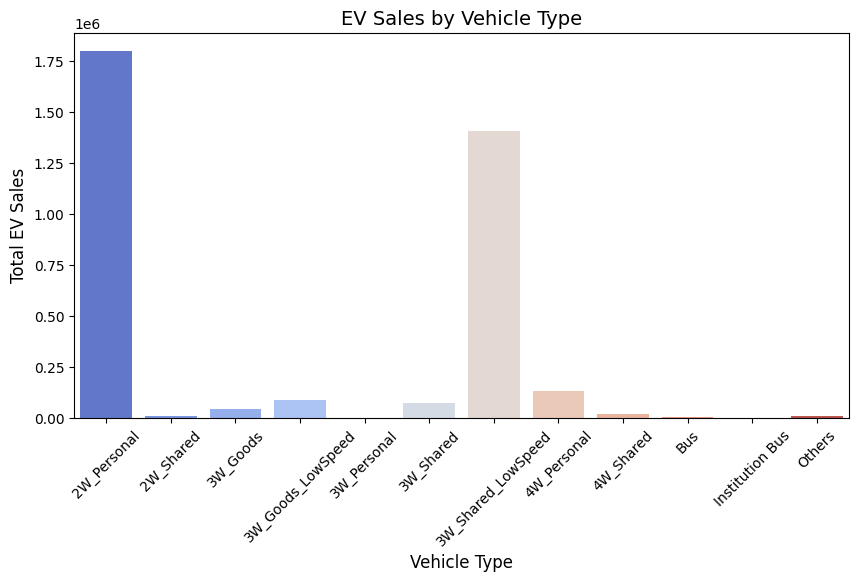

In [11]:
# Aggregate EV sales by Vehicle Type
vehicle_type_sales = df.groupby('Vehicle_Type')['EV_Sales_Quantity'].sum()

# Plot sales by vehicle type
plt.figure(figsize=(10, 5))
sns.barplot(x=vehicle_type_sales.index, y=vehicle_type_sales.values, palette="coolwarm")
plt.xticks(rotation=45)
plt.title("EV Sales by Vehicle Type", fontsize=14)
plt.xlabel("Vehicle Type", fontsize=12)
plt.ylabel("Total EV Sales", fontsize=12)
plt.show()

Forecasted EV Sales for Next 12 Months:
[8.91520029e-30 6.96819472e-31 1.09391887e-30 1.49392988e-30
 1.83972865e-30 2.29914243e-30 2.66333994e-30 1.70252912e-30
 1.86945856e-30 1.98711844e-30 2.05410190e-30 2.08773030e-30]

Projected Revenue for Next 12 Months:
[-500000. -500000. -500000. -500000. -500000. -500000. -500000. -500000.
 -500000. -500000. -500000. -500000.]


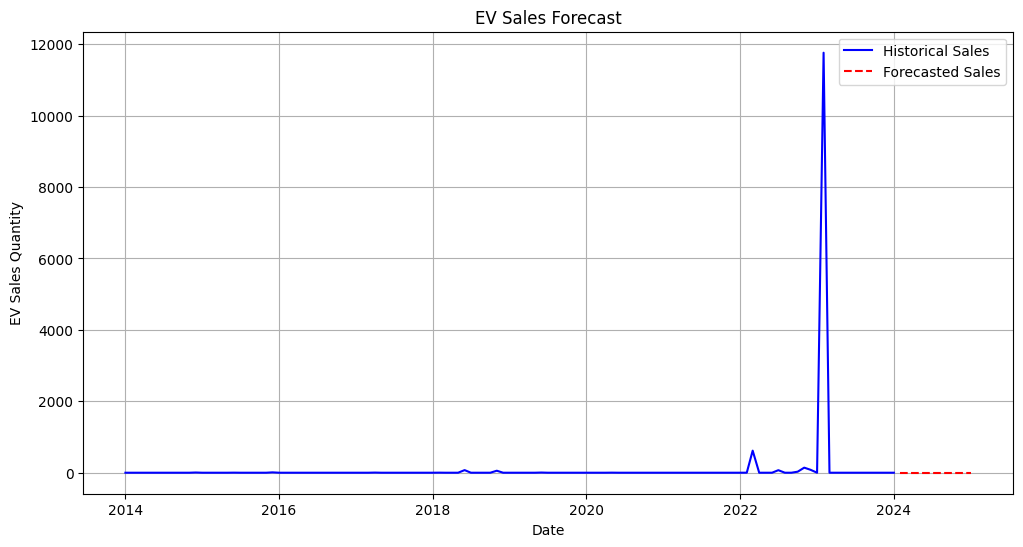

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA

# Load data
ev_df = pd.read_csv(r"C:\Users\Aparna Mondal\Downloads\EV_Dataset.csv")

# Clean dataset
electric_vehicle_sales = ev_df[['Year', 'Month_Name', 'EV_Sales_Quantity']].dropna()

# Convert 'Year' and 'Month_Name' to datetime
electric_vehicle_sales['Date'] = pd.to_datetime(
    electric_vehicle_sales['Year'].astype(int).astype(str) + '-' + electric_vehicle_sales['Month_Name'], 
    format='%Y-%b', errors='coerce'
)

# Drop rows with invalid dates and duplicates
electric_vehicle_sales = electric_vehicle_sales.dropna(subset=['Date'])
electric_vehicle_sales = electric_vehicle_sales.sort_values(by='Date')
electric_vehicle_sales = electric_vehicle_sales.drop_duplicates(subset='Date')

# Set datetime as index and set frequency
electric_vehicle_sales = electric_vehicle_sales.set_index('Date').asfreq('MS')

# Forward fill any missing sales values
electric_vehicle_sales['EV_Sales_Quantity'] = electric_vehicle_sales['EV_Sales_Quantity'].ffill()

# Fit ARIMA model
model = ARIMA(electric_vehicle_sales['EV_Sales_Quantity'], order=(5,1,0))
model_fit = model.fit()

# Forecast next 12 months
forecast = model_fit.forecast(steps=12)

# Revenue estimation
ev_price = 40000  # Estimated average EV price
operational_costs = 500000  # Fixed yearly operational costs
total_revenue = (forecast.values * ev_price) - operational_costs

# Display results
print("Forecasted EV Sales for Next 12 Months:")
print(forecast.values)

print("\nProjected Revenue for Next 12 Months:")
print(total_revenue)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(electric_vehicle_sales['EV_Sales_Quantity'], label='Historical Sales', color='blue')

# Generate forecast dates
forecast_index = pd.date_range(start=electric_vehicle_sales.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')
plt.plot(forecast_index, forecast.values, linestyle='dashed', color='red', label='Forecasted Sales')

plt.xlabel('Date')
plt.ylabel('EV Sales Quantity')
plt.title('EV Sales Forecast')
plt.legend()
plt.grid()
plt.show()


In [17]:
print(electric_vehicle_sales.index.duplicated().sum())  # Count duplicate dates in the index



0


In [24]:
# Create the Date column from Year and Month_Name
electric_vehicle_sales['Date'] = pd.to_datetime(
    electric_vehicle_sales['Year'].astype(str) + '-' + electric_vehicle_sales['Month_Name'],
    format='%Y-%b',
    errors='coerce'
)


Forecasted EV Sales for Next 12 Months:
[140446.6880313  141689.70091649 141787.05909919 141757.58911168
 141868.23069345 141718.63011873 141786.59576846 141750.16568323
 141770.16333386 141766.45425507 141765.7399191  141767.25816893]

Projected Revenue for Next 12 Months:
[5.61736752e+09 5.66708804e+09 5.67098236e+09 5.66980356e+09
 5.67422923e+09 5.66824520e+09 5.67096383e+09 5.66950663e+09
 5.67030653e+09 5.67015817e+09 5.67012960e+09 5.67019033e+09]


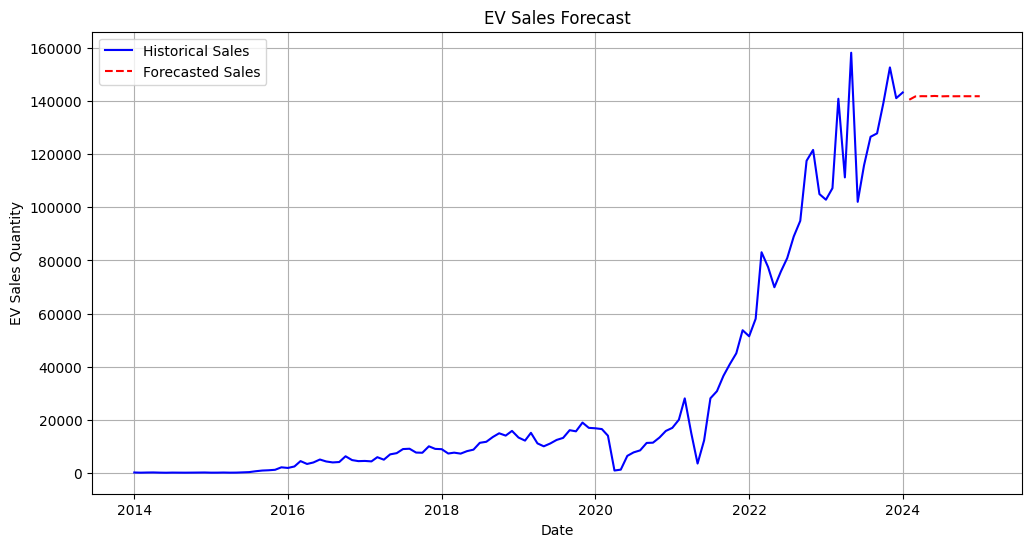

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Load data
ev_df = pd.read_csv(r"C:\Users\Aparna Mondal\Downloads\EV_Dataset.csv")

# Keep only relevant columns and drop missing values
electric_vehicle_sales = ev_df[['Year', 'Month_Name', 'EV_Sales_Quantity']].dropna()

# Create a 'Date' column from 'Year' and 'Month_Name'
electric_vehicle_sales['Date'] = pd.to_datetime(
    electric_vehicle_sales['Year'].astype(int).astype(str) + '-' + electric_vehicle_sales['Month_Name'],
    format='%Y-%b', errors='coerce'
)

# Drop rows with invalid dates
electric_vehicle_sales = electric_vehicle_sales.dropna(subset=['Date'])

# Group by Date to avoid duplicates and aggregate sales
electric_vehicle_sales = electric_vehicle_sales.groupby('Date', as_index=False).sum()

# Sort and set the Date column as index
electric_vehicle_sales = electric_vehicle_sales.sort_values(by='Date').set_index('Date')

# Set frequency and fill missing data
electric_vehicle_sales = electric_vehicle_sales.asfreq('MS')
electric_vehicle_sales['EV_Sales_Quantity'] = electric_vehicle_sales['EV_Sales_Quantity'].ffill()

# ARIMA Model
model = ARIMA(electric_vehicle_sales['EV_Sales_Quantity'], order=(5,1,0))
model_fit = model.fit()

# Forecast next 12 months
forecast = model_fit.forecast(steps=12)

# Revenue Estimation
ev_price = 40000
operational_costs = 500000
total_revenue = (forecast.values * ev_price) - operational_costs

# Display results
print("Forecasted EV Sales for Next 12 Months:")
print(forecast.values)
print("\nProjected Revenue for Next 12 Months:")
print(total_revenue)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(electric_vehicle_sales['EV_Sales_Quantity'], label='Historical Sales', color='blue')
forecast_index = pd.date_range(start=electric_vehicle_sales.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')
plt.plot(forecast_index, forecast.values, linestyle='dashed', color='red', label='Forecasted Sales')
plt.xlabel('Date')
plt.ylabel('EV Sales Quantity')
plt.title('EV Sales Forecast')
plt.legend()
plt.grid()
plt.show()


In [28]:
print(electric_vehicle_sales.dtypes)


Year                 float64
Month_Name            object
EV_Sales_Quantity    float64
dtype: object


In [29]:
electric_vehicle_sales['EV_Sales_Quantity'] = pd.to_numeric(electric_vehicle_sales['EV_Sales_Quantity'], errors='coerce')


In [30]:
electric_vehicle_sales.dropna(subset=['EV_Sales_Quantity'], inplace=True)


In [31]:
print(electric_vehicle_sales.isnull().sum())  # Check for NaNs


Year                 0
Month_Name           0
EV_Sales_Quantity    0
dtype: int64


In [32]:
electric_vehicle_sales.dropna(subset=['EV_Sales_Quantity'], inplace=True)


In [34]:
sales_series = electric_vehicle_sales['EV_Sales_Quantity'].asfreq('MS')


In [35]:
sales_series = electric_vehicle_sales['EV_Sales_Quantity']
sales_series = sales_series.asfreq('MS')


In [36]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA Model
model = ARIMA(sales_series, order=(5,1,0))
model_fit = model.fit()
forecast = model_fit.forecast(steps=12)

# Print forecast
print("Forecasted Sales:", forecast.values)


Forecasted Sales: [140446.6880313  141689.70091649 141787.05909919 141757.58911168
 141868.23069345 141718.63011873 141786.59576846 141750.16568323
 141770.16333386 141766.45425507 141765.7399191  141767.25816893]


**Revenue Estimation**

In [37]:
import numpy as np

# Sample forecasted sales values for 12 months
forecast_values = np.array([140446.6880313, 141689.70091649, 141787.05909919, 141757.58911168,
                            141868.23069345, 141718.63011873, 141786.59576846, 141750.16568323,
                            141770.16333386, 141766.45425507, 141765.7399191, 141767.25816893])

# Constants
ev_price_inr = 3421600  # EV price in INR
operational_costs_inr = 42770000  # Operational costs in INR

# Calculate monthly revenue in INR
monthly_revenue_inr = (ev_price_inr * forecast_values) - operational_costs_inr

# Print projected revenue for each month
print("Projected Revenue for Next 12 Months (in INR):")
print(monthly_revenue_inr)


Projected Revenue for Next 12 Months (in INR):
[4.80509618e+11 4.84762711e+11 4.85095831e+11 4.84994997e+11
 4.85373568e+11 4.84861695e+11 4.85094246e+11 4.84969597e+11
 4.85038021e+11 4.85025330e+11 4.85022886e+11 4.85028081e+11]


**Visualizing the Forecast**

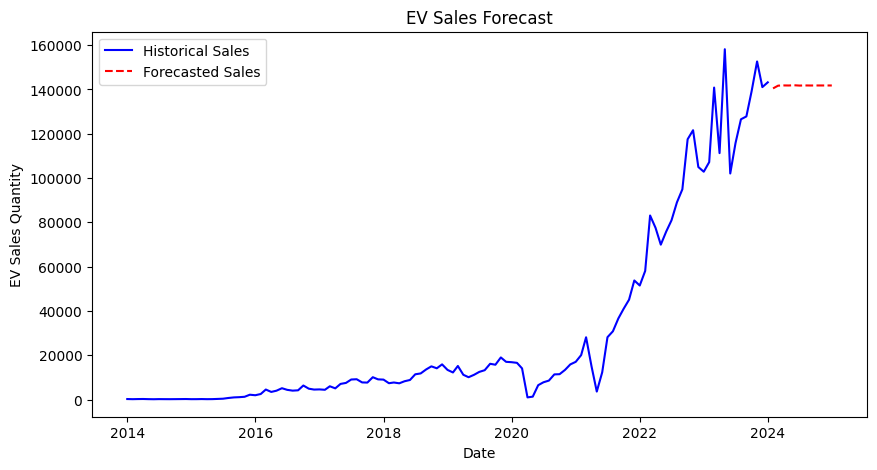

In [38]:
import matplotlib.pyplot as plt

# Generate future dates
future_dates = pd.date_range(start=sales_series.index[-1], periods=12, freq='ME')
# Plot the sales forecast
plt.figure(figsize=(10, 5))
plt.plot(sales_series, label='Historical Sales', color='blue')
plt.plot(future_dates, forecast.values, label='Forecasted Sales', linestyle='dashed', color='red')
plt.xlabel('Date')
plt.ylabel('EV Sales Quantity')
plt.title('EV Sales Forecast')
plt.legend()
plt.show()




In [39]:
def calculate_revenue(unit_price, sales, operational_costs):
    return (unit_price * sales) - operational_costs

unit_price = 500000
sales = 300
operational_costs = 2000000

revenue = calculate_revenue(unit_price, sales, operational_costs)
print(f"Total Revenue: ₹{revenue}")

Total Revenue: ₹148000000


In [40]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns

# Initialize LabelEncoder
le = LabelEncoder()

# Apply Label Encoding to each categorical column
for col in categorical_columns:
    df[col] = le.fit_transform(df[col].astype(str))

print("Categorical columns encoded successfully!")


Categorical columns encoded successfully!


In [41]:
le = LabelEncoder()
for col in categorical_columns:
    df[col] = le.fit_transform(df[col].astype(str))

In [42]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling only to numerical columns
df_scaled = scaler.fit_transform(df[numerical_columns])

# Convert the scaled data back to a DataFrame
df_scaled = pd.DataFrame(df_scaled, columns=numerical_columns)

print("Numerical columns scaled successfully!")


Numerical columns scaled successfully!


In [43]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[numerical_columns])

In [44]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Segment'] = kmeans.fit_predict(df_scaled)

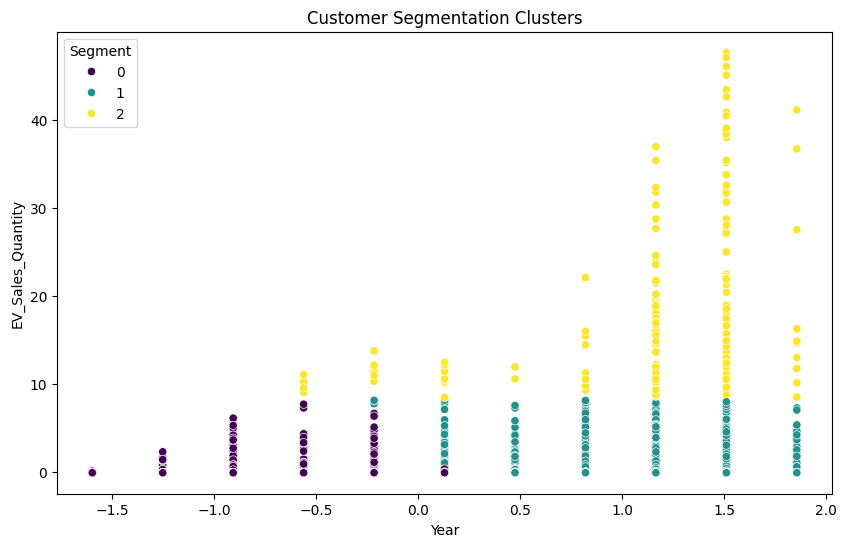

In [45]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_scaled[:, 0], y=df_scaled[:, 1], hue=df['Segment'], palette='viridis')
plt.title("Customer Segmentation Clusters")
plt.xlabel(numerical_columns[0])
plt.ylabel(numerical_columns[1])
plt.show()


In [46]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)  # or any value for clusters
df['Segment'] = kmeans.fit_predict(df_scaled)


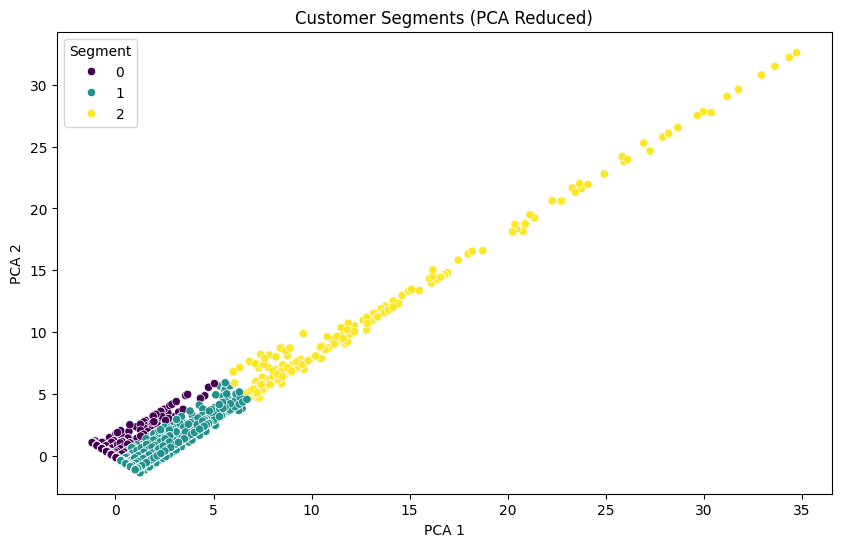

In [47]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_components[:, 0], y=pca_components[:, 1], hue=df['Segment'], palette='viridis')
plt.title("Customer Segments (PCA Reduced)")
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()


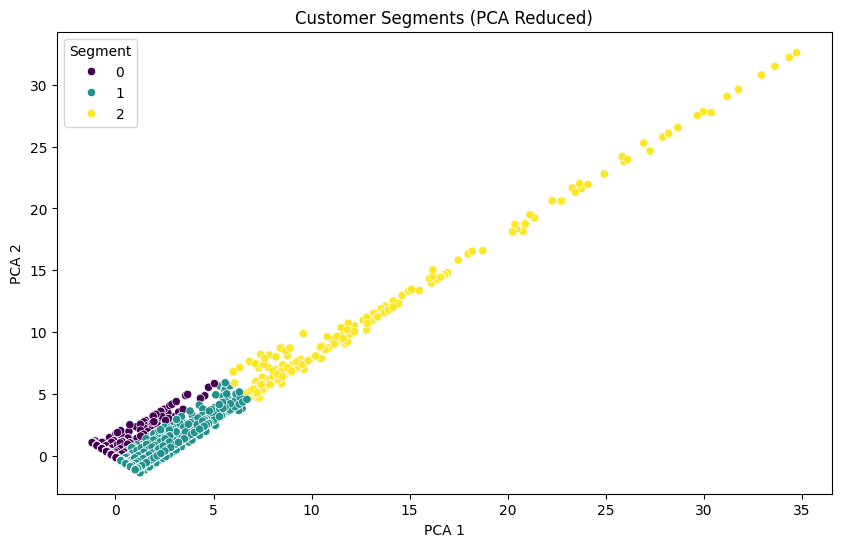

In [48]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_components[:, 0], y=pca_components[:, 1], hue=df['Segment'], palette='viridis')
plt.title("Customer Segments (PCA Reduced)")
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()


In [49]:
segment_summary = df.groupby('Segment')[numerical_columns].mean()
print(segment_summary)


                Year  EV_Sales_Quantity
Segment                                
0        2016.585551           4.339498
1        2021.614092          42.612270
2        2022.213675        7192.149573


1. Visualize Trends Per Segment

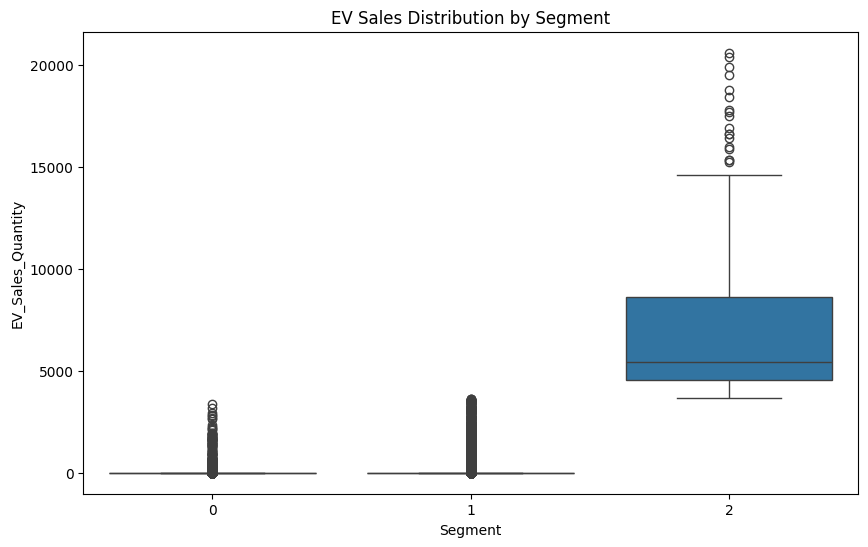

In [50]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Segment', y='EV_Sales_Quantity', data=df)
plt.title("EV Sales Distribution by Segment")
plt.show()


Forecast Future Sales for the Booming Segment (Segment 2)

In [53]:
# Convert float year to datetime (e.g., 2022.213675 to a proper date)
segment_2['Date'] = pd.to_datetime(segment_2['Year'], format='%Y', errors='coerce')


C:\Users\Aparna Mondal\AppData\Local\Temp\ipykernel_24532\3074650424.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  segment_2['Date'] = pd.to_datetime(segment_2['Year'], format='%Y', errors='coerce')


In [55]:
print(segment_2['Year'].describe())
print(segment_2['Year'].sort_values(ascending=False).head(10))  # Look at top 10 large years


count     234.000000
mean     2022.213675
std         1.449162
min      2017.000000
25%      2022.000000
50%      2023.000000
75%      2023.000000
max      2024.000000
Name: Year, dtype: float64
8832    2024.0
8061    2024.0
8792    2024.0
8739    2024.0
8543    2024.0
8365    2024.0
8356    2024.0
8288    2024.0
8251    2024.0
8202    2024.0
Name: Year, dtype: float64


In [56]:
# Keep only reasonable years (say up to 2100)
segment_2 = segment_2[segment_2['Year'] <= 2100]


In [57]:
# This will convert float years (e.g., 2022.213675) to approximate datetime objects
segment_2['Date'] = pd.to_datetime(
    segment_2['Year'].apply(lambda x: f"{int(x)}-01-01"), format="%Y-%m-%d"
)


In [58]:
from datetime import datetime, timedelta

# Function to convert float year to datetime
def float_year_to_datetime(year_float):
    year = int(year_float)
    start = datetime(year, 1, 1)
    end = datetime(year + 1, 1, 1)
    fraction = year_float - year
    return start + (end - start) * fraction

# Apply conversion
segment_2['Date'] = segment_2['Year'].apply(float_year_to_datetime)


In [59]:
segment_2['Date'] = pd.to_datetime(segment_2['Year'].astype(str).str[:7], format="%Y.%m", errors='coerce')


In [61]:
print(df.columns)


Index(['Year', 'Month_Name', 'Date', 'State', 'Vehicle_Class',
       'Vehicle_Category', 'Vehicle_Type', 'EV_Sales_Quantity'],
      dtype='object')


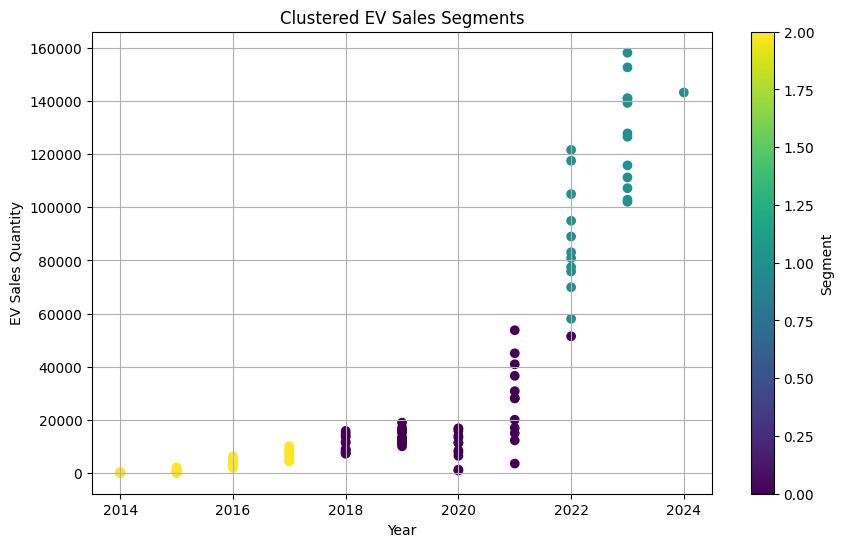

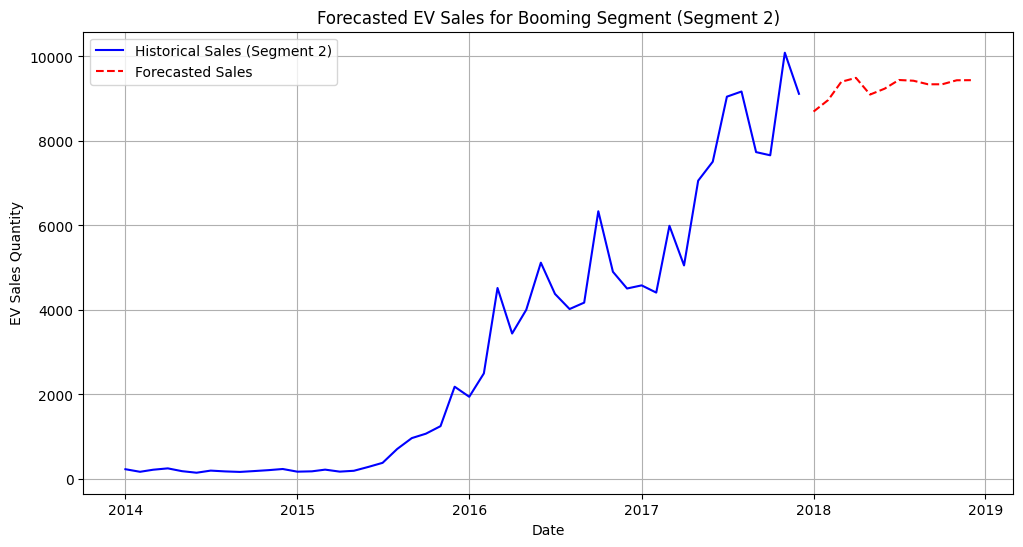

Forecasted Sales for Segment 2: [8694.19994067 8967.29024799 9399.83885753 9491.89886131 9097.36531233
 9236.96662063 9441.72159528 9424.50688739 9340.21665342 9340.04684953
 9435.34835383 9437.57906554]
Projected Revenue for Segment 2: [3.47267998e+08 3.58191610e+08 3.75493554e+08 3.79175954e+08
 3.63394612e+08 3.68978665e+08 3.77168864e+08 3.76480275e+08
 3.73108666e+08 3.73101874e+08 3.76913934e+08 3.77003163e+08]


In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from statsmodels.tsa.arima.model import ARIMA

# Load your dataset
df = pd.read_csv(r"C:\Users\Aparna Mondal\Downloads\EV_Dataset.csv")

# Create Date column
df['Date'] = pd.to_datetime(
    df['Year'].astype(int).astype(str) + '-' + df['Month_Name'],
    format='%Y-%b', errors='coerce'
)

df = df.dropna(subset=['Date'])

# Group by Date to aggregate sales
grouped_df = df.groupby('Date', as_index=False).agg({'EV_Sales_Quantity': 'sum', 'Year': 'first'})

# Standardize for clustering
scaler = StandardScaler()
scaled_data = scaler.fit_transform(grouped_df[['EV_Sales_Quantity', 'Year']])

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
grouped_df['Segment'] = kmeans.fit_predict(scaled_data)

# Plot to visualize clusters
plt.figure(figsize=(10, 6))
plt.scatter(grouped_df['Year'], grouped_df['EV_Sales_Quantity'], c=grouped_df['Segment'], cmap='viridis')
plt.xlabel('Year')
plt.ylabel('EV Sales Quantity')
plt.title('Clustered EV Sales Segments')
plt.colorbar(label='Segment')
plt.grid()
plt.show()

# Filter booming segment (Segment 2)
segment_2_df = grouped_df[grouped_df['Segment'] == 2].copy()
segment_2_df = segment_2_df.sort_values('Date').set_index('Date')
segment_2_df = segment_2_df.asfreq('MS')
segment_2_df['EV_Sales_Quantity'] = segment_2_df['EV_Sales_Quantity'].ffill()

# Forecast sales for Segment 2
model = ARIMA(segment_2_df['EV_Sales_Quantity'], order=(5,1,0))
model_fit = model.fit()
forecast = model_fit.forecast(steps=12)

# Plot forecast
plt.figure(figsize=(12, 6))
plt.plot(segment_2_df['EV_Sales_Quantity'], label='Historical Sales (Segment 2)', color='blue')
future_index = pd.date_range(start=segment_2_df.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')
plt.plot(future_index, forecast.values, linestyle='dashed', color='red', label='Forecasted Sales')
plt.title('Forecasted EV Sales for Booming Segment (Segment 2)')
plt.xlabel('Date')
plt.ylabel('EV Sales Quantity')
plt.legend()
plt.grid()
plt.show()

# Optional: Revenue Estimation
ev_price = 40000
operational_costs = 500000
projected_revenue = (forecast.values * ev_price) - operational_costs

print("Forecasted Sales for Segment 2:", forecast.values)
print("Projected Revenue for Segment 2:", projected_revenue)


In [63]:
estimated_revenue = (forecast.values * 40000) - 500000
print("Estimated Revenue from Segment 2 (Next 12 months):")
print(estimated_revenue)


Estimated Revenue from Segment 2 (Next 12 months):
[3.47267998e+08 3.58191610e+08 3.75493554e+08 3.79175954e+08
 3.63394612e+08 3.68978665e+08 3.77168864e+08 3.76480275e+08
 3.73108666e+08 3.73101874e+08 3.76913934e+08 3.77003163e+08]


Business Model – Canvas Diagram

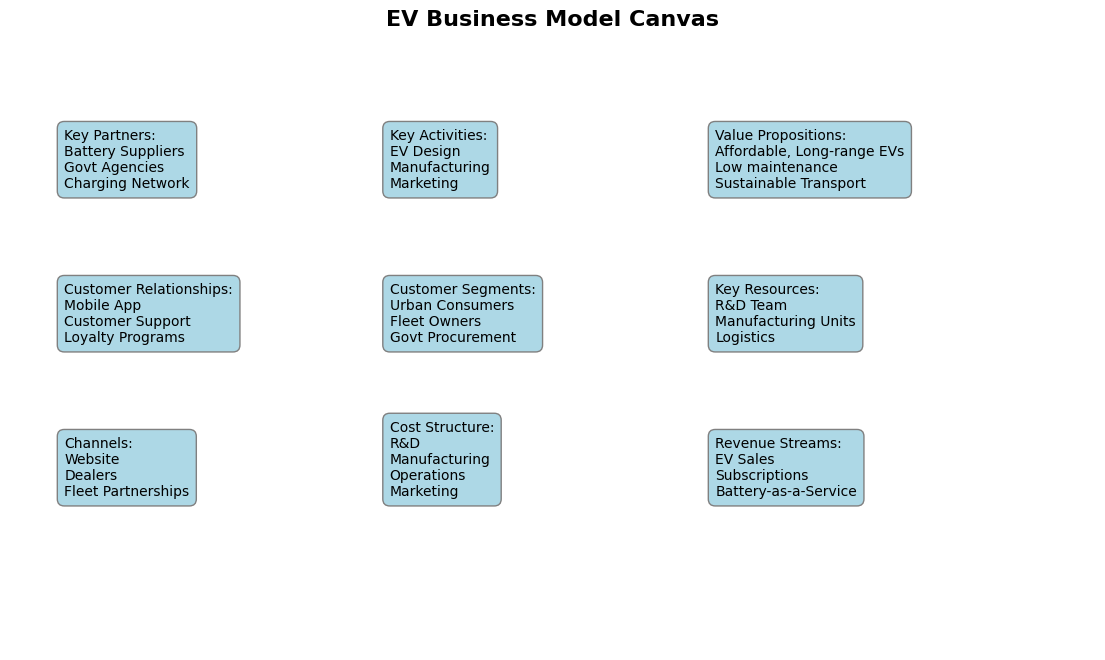

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
plt.axis('off')
plt.title("EV Business Model Canvas", fontsize=16, fontweight='bold')

canvas = {
    "Key Partners": ["Battery Suppliers", "Govt Agencies", "Charging Network"],
    "Key Activities": ["EV Design", "Manufacturing", "Marketing"],
    "Value Propositions": ["Affordable, Long-range EVs", "Low maintenance", "Sustainable Transport"],
    "Customer Relationships": ["Mobile App", "Customer Support", "Loyalty Programs"],
    "Customer Segments": ["Urban Consumers", "Fleet Owners", "Govt Procurement"],
    "Key Resources": ["R&D Team", "Manufacturing Units", "Logistics"],
    "Channels": ["Website", "Dealers", "Fleet Partnerships"],
    "Cost Structure": ["R&D", "Manufacturing", "Operations", "Marketing"],
    "Revenue Streams": ["EV Sales", "Subscriptions", "Battery-as-a-Service"],
}

positions = [
    (0.05, 0.75, 'Key Partners'), (0.35, 0.75, 'Key Activities'), (0.65, 0.75, 'Value Propositions'),
    (0.05, 0.5, 'Customer Relationships'), (0.35, 0.5, 'Customer Segments'), (0.65, 0.5, 'Key Resources'),
    (0.05, 0.25, 'Channels'), (0.35, 0.25, 'Cost Structure'), (0.65, 0.25, 'Revenue Streams')
]

for x, y, title in positions:
    plt.text(x, y, f"{title}:\n" + '\n'.join(canvas[title]), fontsize=10, bbox=dict(boxstyle="round,pad=0.5", edgecolor='gray', facecolor='lightblue'))

plt.show()


Financial Equation – Revenue Plot

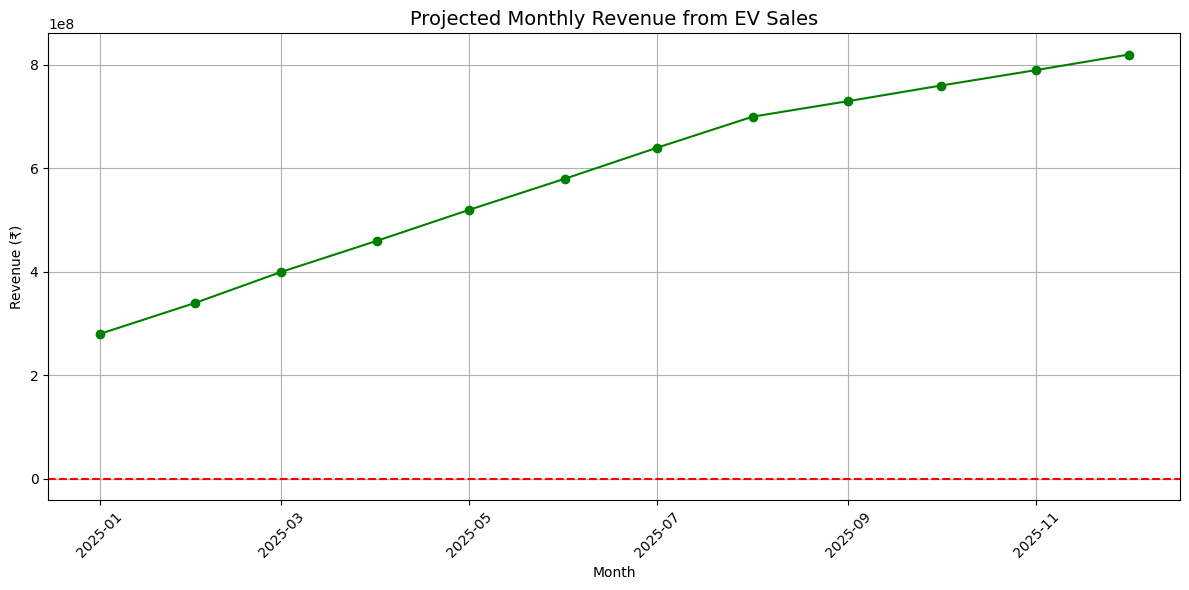

In [65]:
months = pd.date_range(start='2025-01-01', periods=12, freq='MS')
unit_sales = [100, 120, 140, 160, 180, 200, 220, 240, 250, 260, 270, 280]
price = 3000000  # ₹30L
operational_cost = 20000000  # ₹2Cr

monthly_revenue = [(x * price - operational_cost) for x in unit_sales]

plt.figure(figsize=(12, 6))
plt.plot(months, monthly_revenue, marker='o', color='green')
plt.title("Projected Monthly Revenue from EV Sales", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.grid(True)
plt.axhline(0, color='red', linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


 Market Share Trend (Year-wise)

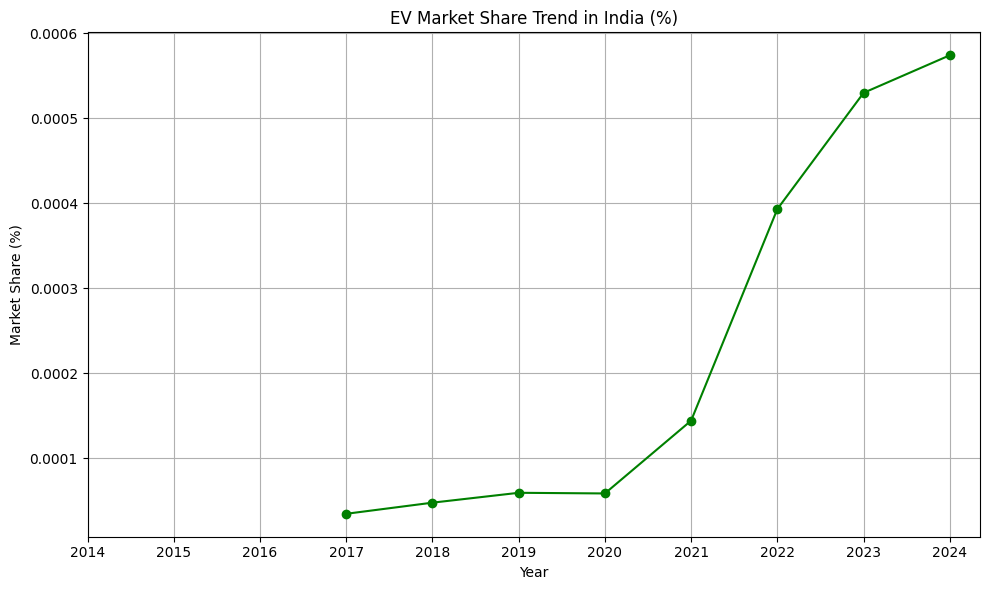

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming you already have ev_df loaded and cleaned
# Add estimated total vehicle sales per year (India, example values)
total_sales_dict = {
    2017: 25500000,
    2018: 26500000,
    2019: 27100000,
    2020: 24400000,
    2021: 24800000,
    2022: 26000000,
    2023: 28000000,
    2024: 29000000,  # Estimation
}

# Map total vehicle sales to your dataset
ev_df['Total_Vehicle_Sales'] = ev_df['Year'].map(total_sales_dict)

# Calculate Market Share (%)
ev_df['Market_Share_%'] = (ev_df['EV_Sales_Quantity'] / ev_df['Total_Vehicle_Sales']) * 100

# Group by year to see yearly trend
market_share_yearly = ev_df.groupby('Year')['Market_Share_%'].mean()

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(market_share_yearly.index, market_share_yearly.values, marker='o', linestyle='-', color='green')
plt.title("EV Market Share Trend in India (%)")
plt.xlabel("Year")
plt.ylabel("Market Share (%)")
plt.grid(True)
plt.xticks(market_share_yearly.index)
plt.tight_layout()
plt.show()



EV Adoption Rate

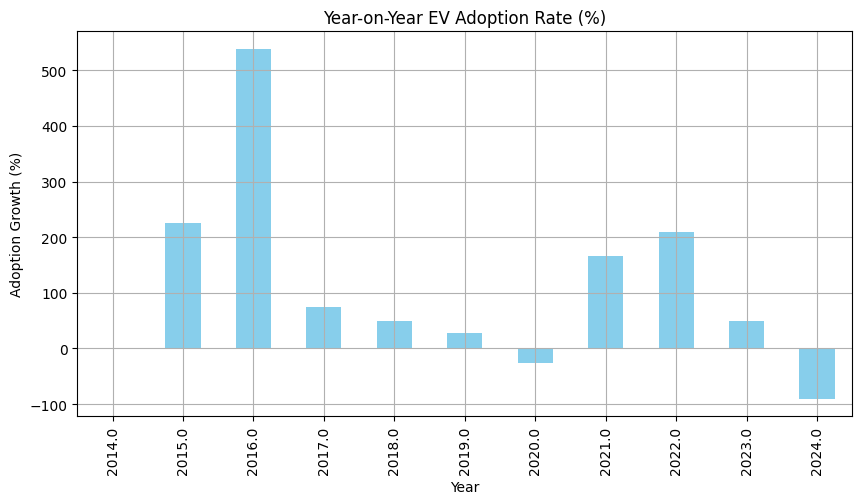

In [70]:
ev_sales_yearly = ev_df.groupby('Year')['EV_Sales_Quantity'].sum()
adoption_rate = ev_sales_yearly.pct_change() * 100

plt.figure(figsize=(10, 5))
adoption_rate.plot(kind='bar', color='skyblue')
plt.title("Year-on-Year EV Adoption Rate (%)")
plt.ylabel("Adoption Growth (%)")
plt.xlabel("Year")
plt.grid()
plt.show()


Operational Cost vs Revenue Analysis

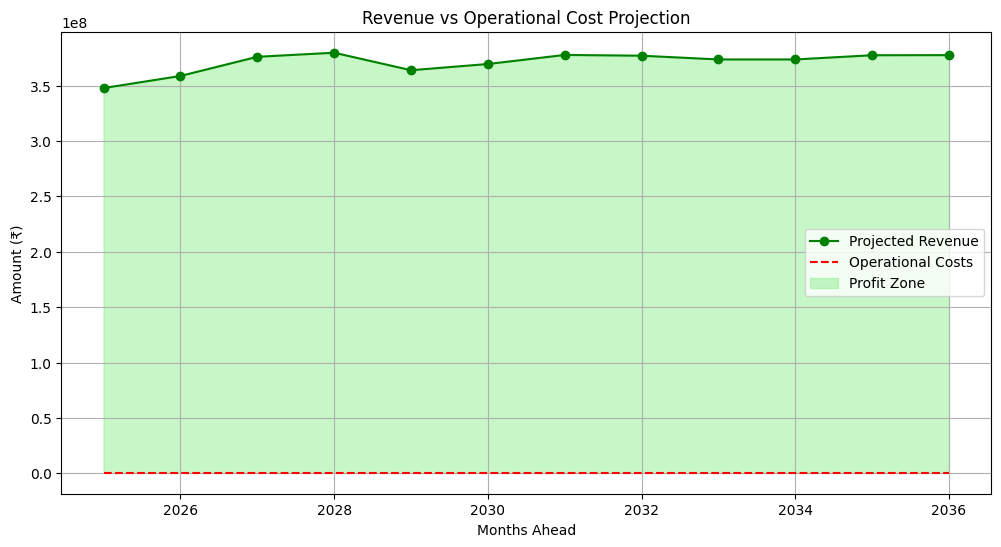

In [71]:
years = [2024 + i for i in range(1, 13)]
revenue = forecast.values * ev_price
costs = [operational_costs] * 12

plt.figure(figsize=(12, 6))
plt.plot(years, revenue, label="Projected Revenue", color="green", marker='o')
plt.plot(years, costs, label="Operational Costs", color="red", linestyle='--')
plt.fill_between(years, revenue, costs, where=(np.array(revenue) > np.array(costs)),
                 interpolate=True, color='lightgreen', alpha=0.5, label='Profit Zone')
plt.title("Revenue vs Operational Cost Projection")
plt.xlabel("Months Ahead")
plt.ylabel("Amount (₹)")
plt.legend()
plt.grid()
plt.show()


Top States by EV Adoption

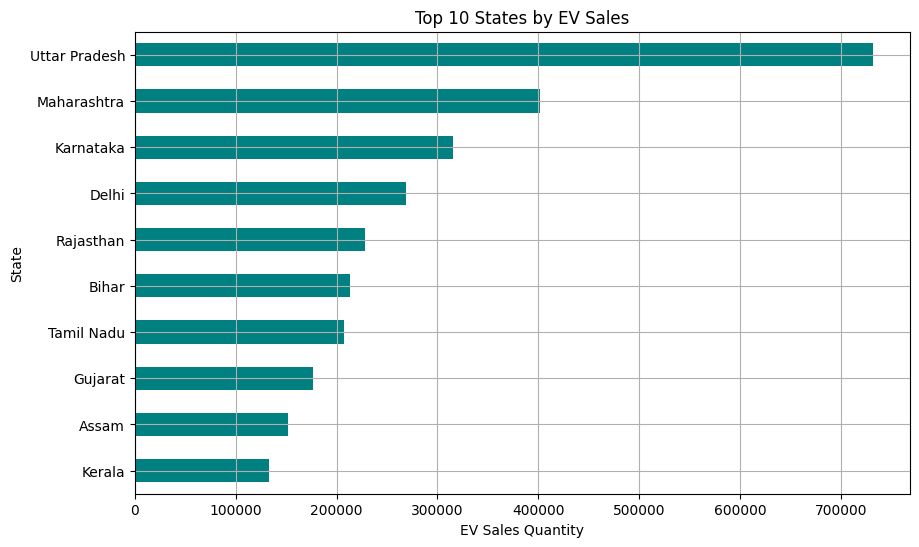

In [72]:
state_sales = ev_df.groupby('State')['EV_Sales_Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
state_sales.plot(kind='barh', color='teal')
plt.title("Top 10 States by EV Sales")
plt.xlabel("EV Sales Quantity")
plt.gca().invert_yaxis()
plt.grid()
plt.show()
